In [13]:
import os
import json
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import numpy as np


In [2]:
BASE_PATH = "/home/aegis/ether/Research_HEP/Dataset_ver4/MC/reduce_root"
METADATA_PATH = "mc_metadata.json"

LUMI = 36100.0  # in pb^-1 (36.1 fb^-1)
REDUCTION = 0.6 # You processed 60% of total files

with open("mc_metadata.json", "r") as f:
    METADATA = json.load(f)


BRANCHES = [
    # --- Global Event & MET ---
    "MET_Core_AnalysisMETAuxDyn_mpx",
    "MET_Core_AnalysisMETAuxDyn_mpy",
    "MET_Core_AnalysisMETAuxDyn_sumet",
    "EventInfoAuxDyn_mcEventWeights",
    "EventInfoAuxDyn_DFCommonJets_eventClean_LooseBad", # Required for jet cleaning
    "EventInfoAuxDyn_runNumber", 
    
    # --- Small-R Jets (Selection & Cleaning) ---
    "AnalysisJetsAuxDyn_pt",
    "AnalysisJetsAuxDyn_eta",
    "AnalysisJetsAuxDyn_phi",
    "AnalysisJetsAuxDyn_NNJvtPass",
    "AnalysisJetsAuxDyn_SumPtTrkPt500",    # Required for f_ch cleaning
    "AnalysisJetsAuxDyn_EnergyPerSampling", # Required for f_max cleaning
    "AnalysisJetsAuxDyn_NumTrkPt500",       # Required for Overlap Removal logic
    
    # --- Large-R Jets (AD Features - Expanded) ---
    "AnalysisLargeRJetsAuxDyn_pt",
    "AnalysisLargeRJetsAuxDyn_eta",
    "AnalysisLargeRJetsAuxDyn_phi",
    "AnalysisLargeRJetsAuxDyn_m",
    "AnalysisLargeRJetsAuxDyn_Tau1_wta",
    "AnalysisLargeRJetsAuxDyn_Tau2_wta",
    "AnalysisLargeRJetsAuxDyn_Tau3_wta",
    "AnalysisLargeRJetsAuxDyn_D2", # Highly recommended for AD
    "AnalysisLargeRJetsAuxDyn_C2", # Highly recommended for AD
    
    # --- Lepton & Tau Vetoes ---
    "AnalysisElectronsAuxDyn_pt",
    "AnalysisElectronsAuxDyn_eta",
    "AnalysisElectronsAuxDyn_phi",
    "AnalysisElectronsAuxDyn_DFCommonElectronsLHTight",
    "AnalysisMuonsAuxDyn_pt",
    "AnalysisMuonsAuxDyn_eta",
    "AnalysisMuonsAuxDyn_phi",
    "AnalysisMuonsAuxDyn_muonType",
    "AnalysisMuonsAuxDyn_quality",
    "AnalysisTauJetsAuxDyn_pt",
    "AnalysisTauJetsAuxDyn_eta",
    "AnalysisTauJetsAuxDyn_phi",
    "AnalysisTauJetsAuxDyn_JetDeepSetTight",
    
    # --- Flavor Tagging ---
    "BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pu",
    "BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pc",
    "BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pb"
]


In [ ]:
def load_mc_events(split_type, branches, process="ttbar"):
    """
    split_type: 'train' (40%), 'val' (20%), 'ad' (20%), 'inference' (20%)
    branches: List of branch names to read from the ROOT files
    """
    # 1. Get and Sort Files Numerically
    ttbar_path = os.path.join(BASE_PATH, process)
    all_subprocesses = []

    # Iterate through: PhPy8EG_A14_ttbar_hdamp258p75_nonallhad, etc.
    for subp in METADATA[process].keys():
        subp_dir = os.path.join(ttbar_path, f"mc20_13TeV_MC_{subp}")
        print(f"Checking directory: {subp_dir}")
        # subp_path = os.path.join(ttbar_path, subp)
        # print(os.listdir(subp_path))
        if not os.path.exists(subp_dir):
            continue

        print(f"Processing subprocess: {subp}")
        
        # 1. Get and Sort Files Numerically
        files = sorted([os.path.join(subp_dir, f) for f in os.listdir(subp_dir) if f.endswith(".root")])
        n = len(files)

        # 2. File-Level Splitting Logic
        if split_type == "train":
            selected = files[:int(0.4 * n)]
        elif split_type == "val":
            selected = files[int(0.4 * n):int(0.6 * n)]
        elif split_type == "ad":
            selected = files[int(0.6 * n):int(0.8 * n)]
        else: # inference
            selected = files[int(0.8 * n):]

        if not selected:    
            continue
        print(f"Loading {len(selected)} files for {subp} ({split_type})...")
        try: 
            events = uproot.concatenate([f + ":CollectionTree" for f in selected], branches)
        
            # Physics Weight Calculation: (Cross-Section * Lumi) / (Sum of Weights * 0.6)
            meta = METADATA[process][subp]
            norm = (meta['xsec_pb'] * LUMI) / (meta['sum_w'] * REDUCTION)
            
            # Generator weights are in a vector; usually we take index 0
            events["weight_phys"] = events["EventInfoAuxDyn_mcEventWeights"][:, 0] * norm
            all_subprocesses.append(events)
        except Exception as e:
            print(f"Error loading {subp}: {e}")
            continue
    # Combine nonallhad and allhad into one ttbar array
    return ak.concatenate(all_subprocesses)

ttbar_events_train = load_mc_events("train", branches=BRANCHES, process="ttbar")
diboson_events_train = load_mc_events("train", branches=BRANCHES, process="Diboson")
single_top_events_train = load_mc_events("train", branches=BRANCHES, process="Single_top")
multijet_events_train = load_mc_events("train", branches=BRANCHES, process="Multijet")
wjets_events_train = load_mc_events("train", branches=BRANCHES, process="Wjets")
zjets_events_train = load_mc_events("train", branches=BRANCHES, process="Zjets")

print("Data loading complete.")

Checking directory: /home/aegis/ether/Research_HEP/Dataset_ver4/MC/reduce_root/ttbar/mc20_13TeV_MC_PhPy8EG_A14_ttbar_hdamp258p75_nonallhad
Processing subprocess: PhPy8EG_A14_ttbar_hdamp258p75_nonallhad
Loading 45 files for PhPy8EG_A14_ttbar_hdamp258p75_nonallhad (train)...
Checking directory: /home/aegis/ether/Research_HEP/Dataset_ver4/MC/reduce_root/ttbar/mc20_13TeV_MC_PhPy8EG_A14_ttbar_hdamp258p75_allhad
Processing subprocess: PhPy8EG_A14_ttbar_hdamp258p75_allhad
Loading 35 files for PhPy8EG_A14_ttbar_hdamp258p75_allhad (train)...
Checking directory: /home/aegis/ether/Research_HEP/Dataset_ver4/MC/reduce_root/Diboson/mc20_13TeV_MC_Sh_2211_WlvWqq
Processing subprocess: Sh_2211_WlvWqq
Loading 5 files for Sh_2211_WlvWqq (train)...
Checking directory: /home/aegis/ether/Research_HEP/Dataset_ver4/MC/reduce_root/Diboson/mc20_13TeV_MC_Sh_2211_WlvZqq
Processing subprocess: Sh_2211_WlvZqq
Loading 2 files for Sh_2211_WlvZqq (train)...
Checking directory: /home/aegis/ether/Research_HEP/Dataset_ve

In [4]:
def calc_dr_matrix(eta1, phi1, eta2, phi2):
        # Create a grid to compare every object in collection 1 to every object in collection 2
        deta = eta1[:, :, np.newaxis] - eta2[:, np.newaxis, :]
        dphi = np.abs(phi1[:, :, np.newaxis] - phi2[:, np.newaxis, :])
        dphi = ak.where(dphi > np.pi, 2*np.pi - dphi, dphi)
        return np.sqrt(deta**2 + dphi**2)

def lepton_selection(events):
    """
    ATLAS Paper Lepton Selection 
    """
    w_initial = ak.sum(events["weight_phys"])

    # --- 1. Electron Selection ---
    ele_pt = events["AnalysisElectronsAuxDyn_pt"] / 1000.0
    ele_eta = events["AnalysisElectronsAuxDyn_eta"]
    # DFCommonElectronsLHTight is a boolean for the "Likelihood Tight" ID
    ele_id = events["AnalysisElectronsAuxDyn_DFCommonElectronsLHTight"] == 1
    # Standard cuts: pT > 7 GeV, |eta| < 2.5 (excluding crack region 1.37-1.52)
    ele_kin_mask = (ele_pt > 7) & (abs(ele_eta) < 2.5) & ((abs(ele_eta) < 1.37) | (abs(ele_eta) > 1.52))
    good_electrons = ele_id & ele_kin_mask

    # --- 2. Muon Selection ---
    mu_pt = events["AnalysisMuonsAuxDyn_pt"] / 1000.0
    mu_eta = events["AnalysisMuonsAuxDyn_eta"]
    
    # Selection criteria based on professor's verification:
    # Quality 8 or 9 for Medium
    mu_quality = (events["AnalysisMuonsAuxDyn_quality"] == 8) | \
                 (events["AnalysisMuonsAuxDyn_quality"] == 9)
    
    # Combined Muon Type (Type == 0)
    mu_type = events["AnalysisMuonsAuxDyn_muonType"] == 0
    
    # Kinematics: pT > 7 GeV, |eta| < 2.5
    mu_kin = (mu_pt > 7) & (abs(mu_eta) < 2.5)
    
    good_muons = mu_quality & mu_type & mu_kin

    # --- 3. Tau Selection (Veto Candidates) ---
    tau_pt = events["AnalysisTauJetsAuxDyn_pt"] / 1000.0
    tau_eta = events["AnalysisTauJetsAuxDyn_eta"]
    # RNN identification: JetDeepSetTight
    tau_id = events["AnalysisTauJetsAuxDyn_JetDeepSetTight"] == 1
    
    # Standard Tau acceptance: pT > 20 GeV, |eta| < 2.5
    tau_kin = (tau_pt > 20) & (abs(tau_eta) < 2.5)
    good_taus = tau_id & tau_kin

    return good_electrons, good_muons, good_taus

def event_cleaning(events):
    """ 
    ATLAS Paper Selection 
    1. Events must have at least one reconstructed vertex with at least two associated tracks with pT > 500 MeV
    2. Events are required to have at least two jets within |𝜂| < 2.8, the leading jet is required to have pT > 250 GeV
    3. Requirements on the jet-vertex tagger discriminant are applied to jets with pT below 60 GeV
    4. At least one jet within Δϕ = 2.0 of the MET direction.
    5. b-jet veto: Events with two or more b-tagged jets (77% WP) are vetoed.
    6. Non-Collision Background (NCB) Veto based on f_ch / f_max for leading jet.
    7. Lepton Selection and Tau Veto
    8. Overlap Removal 
    9. MET Calculation and Selection
    10. Events are required to have at least two large jets
    """
    # --- 1. PV Tracks Selection ---
    w_initial = ak.sum(events["weight_phys"])
    
    trk_data = events["AnalysisJetsAuxDyn_NumTrkPt500"]
    pv_tracks_per_jet = trk_data[:, :, 0]
    total_pv_tracks = ak.fill_none(ak.sum(pv_tracks_per_jet, axis=1), 0)
    
    passing_mask = (total_pv_tracks >= 2)
    
    # Weight Stats
    w_after_pv = ak.sum(events[passing_mask]["weight_phys"])
    print(f"PV Selection: {ak.sum(passing_mask)}/{len(events)} passed ({100*ak.sum(passing_mask)/len(events):.2f}%)")
    print(f"PV Weighted Efficiency: {100 * w_after_pv / w_initial:.2f}%")

    events = events[passing_mask]

    # --- 2. Jet Kinematics Selection ---
    w_initial = ak.sum(events["weight_phys"])

    jet_pt = events["AnalysisJetsAuxDyn_pt"] / 1000.0
    jet_eta = events["AnalysisJetsAuxDyn_eta"]

    # Only look at jets in the tracker volume
    in_acceptance = abs(jet_eta) < 2.8
    accepted_pts = jet_pt[in_acceptance]

    # Requirement: At least 2 jets in acceptance
    has_two_jets = ak.num(accepted_pts, axis=1) >= 2

    # Requirement: Leading jet > 250 GeV
    # Requirement: Sub-leading (index 1) jet > 30 GeV
    leading_pt = ak.pad_none(accepted_pts, 2, axis=1)[:, 0]
    subleading_pt = ak.pad_none(accepted_pts, 2, axis=1)[:, 1]
    
    pass_pts = (ak.fill_none(leading_pt > 250, False)) & (ak.fill_none(subleading_pt > 30, False))

    final_mask_jet = has_two_jets & pass_pts

    # Weight Stats
    w_after_jets = ak.sum(events[final_mask_jet]["weight_phys"])
    print(f"Jet Selection: {ak.sum(final_mask_jet)}/{len(events)} passed ({100*ak.sum(final_mask_jet)/len(events):.2f}%)")
    print(f"Jet Weighted Efficiency: {100 * w_after_jets / w_initial:.2f}%")
    
    events = events[final_mask_jet]
    # --- 3. JVT Cleaning ---
    w_initial = ak.sum(events["weight_phys"])
    jvt_pass = events["AnalysisJetsAuxDyn_NNJvtPass"]
    jet_pt = events["AnalysisJetsAuxDyn_pt"] / 1000.0
    jet_eta = events["AnalysisJetsAuxDyn_eta"]

    # Apply JVT only to jets with pT < 60 GeV and |eta| < 2.4
    low_pt_mask = (jet_pt < 60) & (abs(jet_eta) < 2.4)
    jvt_mask = ak.all(ak.where(low_pt_mask, jvt_pass, True), axis=1)    
    
    w_after_jvt = ak.sum(events[jvt_mask]["weight_phys"])
    print(f"JVT Selection: {ak.sum(jvt_mask)}/{len(events)} events passed ({100*ak.sum(jvt_mask)/len(events):.2f}%)")
    print(f"JVT Weighted Efficiency: {100 * w_after_jvt / w_initial:.2f}%")

    events = events[jvt_mask]

    # --- 4. MET-Jet Delta Phi Selection ---
    w_initial = ak.sum(events["weight_phys"])

    # Calculate MET Phi from components
    met_px = events["MET_Core_AnalysisMETAuxDyn_mpx"][:, 0]
    met_py = events["MET_Core_AnalysisMETAuxDyn_mpy"][:, 0]
    met_phi = np.arctan2(met_py, met_px)

    jet_phi = events["AnalysisJetsAuxDyn_phi"]
    # Calculate Delta Phi and wrap it to [-pi, pi]
    dphi = abs(jet_phi - met_phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)

    # Requirement: At least one jet with dphi < 2.0
    # Note: We usually apply this to all jets or just jets in acceptance? 
    # Standard practice is all "Signal" jets (the ones in AnalysisJets)
    pass_dphi_mask = ak.any(dphi < 2.0, axis=1)
    
    w_after_dphi = ak.sum(events[pass_dphi_mask]["weight_phys"])
    print(f"MET-Jet dPhi Selection: {ak.sum(pass_dphi_mask)}/{len(events)} events passed ({100*ak.sum(pass_dphi_mask)/len(events):.2f}%)")
    print(f"MET-Jet dPhi Weighted Efficiency: {100 * w_after_dphi / w_initial:.2f}%")
    
    events = events[pass_dphi_mask]

    # --- 5. B-Jet Veto ---
    w_initial = ak.sum(events["weight_phys"])

    # 1. Extract probabilities
    pb = events["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pb"]
    pc = events["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pc"]
    pu = events["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pu"]
    
    # 2. Slice to match number of AnalysisJets (7 vs 13 issue)
    n_jets = ak.num(events["AnalysisJetsAuxDyn_pt"])
    pb = pb[ak.local_index(pb) < n_jets]
    pc = pc[ak.local_index(pc) < n_jets]
    pu = pu[ak.local_index(pu) < n_jets]

    # 3. Calculate DL1dv01 Discriminant
    # Small epsilon (1e-10) prevents division by zero
    fc = 0.080
    dl1_score = np.log(pb / (fc * pc + (1 - fc) * pu + 1e-10))

    # 4. Define the 77% Working Point threshold
    # Note: 2.45 is the standard threshold for DL1dv01 @ 77% WP
    is_bjet = dl1_score > 1.42 

    # 5. Requirement: Events with TWO OR MORE b-jets are VETOED
    # This means we keep events where num_bjets < 2
    num_bjets = ak.sum(is_bjet, axis=1)
    bveto_mask = (num_bjets < 2)

    # Weight Stats
    w_after_bveto = ak.sum(events[bveto_mask]["weight_phys"])
    print(f"B-Jet Veto: {ak.sum(bveto_mask)}/{len(events)} events passed ({100*ak.sum(bveto_mask)/len(events):.2f}%)")
    print(f"B-Veto Weighted Efficiency: {100 * w_after_bveto / w_initial:.2f}%")

    events = events[bveto_mask]

    # --- 6. Non-Collision Background (NCB) Veto ---
    w_initial = ak.sum(events["weight_phys"])
    
    # 1. Calculate f_max (Fraction of energy in the single most energetic layer)
    # Sampling energy: [event, jet, layer]
    e_sampling = events["AnalysisJetsAuxDyn_EnergyPerSampling"]
    total_e = ak.sum(e_sampling, axis=2)
    max_e_layer = ak.max(e_sampling, axis=2)
    f_max = max_e_layer / (total_e + 1e-10)
    
    # 2. Calculate f_ch (Charged particle fraction)
    # SumPtTrkPt500 is the total pT of tracks associated with the jet
    sum_pt_track_pv = events["AnalysisJetsAuxDyn_SumPtTrkPt500"][:, :, 0]
    # We normalize track pT by total jet energy as a proxy for f_ch
    f_ch = sum_pt_track_pv / (total_e + 1e-10)
    
    # 3. Requirement: f_ch / f_max > 0.1 for the LEADING JET
    # Pad to ensure we have a leading jet (though previous steps guaranteed it)
    leading_f_ch = ak.pad_none(f_ch, 1, axis=1)[:, 0]
    leading_f_max = ak.pad_none(f_max, 1, axis=1)[:, 0]
    
    # Calculate ratio (with safety epsilon)
    ncb_ratio = leading_f_ch / (leading_f_max + 1e-10)
    ncb_mask = ak.fill_none(ncb_ratio > 0.1, False)
    
    w_after_ncb = ak.sum(events[ncb_mask]["weight_phys"])
    print(f"NCB Cleaning: {ak.sum(ncb_mask)}/{len(events)} events passed ({100*ak.sum(ncb_mask)/len(events):.2f}%)")
    print(f"NCB Weighted Efficiency: {100 * w_after_ncb / w_initial:.2f}%")
    
    events = events[ncb_mask]

    # --- 7. Lepton Selection and Tau Veto ---
    w_initial = ak.sum(events["weight_phys"])
    e_mask, m_mask, tau_mask = lepton_selection(events)
    n_tau = ak.sum(tau_mask, axis=1)

    lepton_mask = (n_tau == 0)

    w_after_lepton = ak.sum(events[lepton_mask]["weight_phys"])
    print(f"Lepton Selection & Tau Veto: {ak.sum(lepton_mask)}/{len(events)} events passed ({100*ak.sum(lepton_mask)/len(events):.2f}%)")
    print(f"Lepton & Tau Weighted Efficiency: {100 * w_after_lepton / w_initial:.2f}%") 

    events = events[lepton_mask]
    # --- 8. Overlap Removal ---
    w_initial = ak.sum(events["weight_phys"])
    e_mask, m_mask, _ = lepton_selection(events)
    # Jets
    j_eta = events["AnalysisJetsAuxDyn_eta"]
    j_phi = events["AnalysisJetsAuxDyn_phi"]
    j_ntrk = events["AnalysisJetsAuxDyn_NumTrkPt500"][:, :, 0]

    e_eta = events["AnalysisElectronsAuxDyn_eta"]
    e_phi = events["AnalysisElectronsAuxDyn_phi"]

    m_eta = events["AnalysisMuonsAuxDyn_eta"]
    m_phi = events["AnalysisMuonsAuxDyn_phi"]

    # A. Electron-Muon: Reject electron if shared track (DR < 0.01)
    dr_e_mu = calc_dr_matrix(e_eta, e_phi, m_eta, m_phi)
    e_mask = e_mask & ak.all(dr_e_mu > 0.01, axis=-1, mask_identity=True)

    # B. Jet-Electron: Remove jet if DR(j, e_selected) < 0.2
    dr_j_e = calc_dr_matrix(j_eta, j_phi, e_eta[e_mask], e_phi[e_mask])
    jet_mask = ak.all(dr_j_e >= 0.2, axis=-1)

    # C. Jet-Muon: Remove jet if DR(j, m_selected) < 0.4 AND nTrk < 3
    dr_j_m = calc_dr_matrix(j_eta, j_phi, m_eta[m_mask], m_phi[m_mask])
    jet_near_mu = ak.any(dr_j_m < 0.4, axis=-1)
    jet_mask = jet_mask & ~(jet_near_mu & (j_ntrk < 3))

    # D. Lepton-Jet: Discard leptons if DR(l, remaining_jets) < 0.4
    dr_e_j = calc_dr_matrix(e_eta, e_phi, j_eta[jet_mask], j_phi[jet_mask])
    e_mask = e_mask & ak.all(dr_e_j >= 0.4, axis=-1)

    dr_m_j = calc_dr_matrix(m_eta, m_phi, j_eta[jet_mask], j_phi[jet_mask])
    m_mask = m_mask & ak.all(dr_m_j >= 0.4, axis=-1)

    n_jets_post_or = ak.sum(jet_mask, axis=1)
    or_event_mask = (n_jets_post_or >= 2)
    
    w_after_or = ak.sum(events[or_event_mask]["weight_phys"])
    print(f"Overlap Removal: {ak.sum(or_event_mask)}/{len(events)} events passed ({100*ak.sum(or_event_mask)/len(events):.2f}%)")
    print(f"OR Weighted Efficiency: {100 * w_after_or / w_initial:.2f}%")


    events = events[or_event_mask]

    jet_mask = jet_mask[or_event_mask]
    e_mask = e_mask[or_event_mask]
    m_mask = m_mask[or_event_mask]

    events["final_jet_mask"] = jet_mask
    events["final_ele_mask"] = e_mask
    events["final_mu_mask"] = m_mask
    # 9. MET Calculation and Selection
    w_initial = ak.sum(events["weight_phys"])
    # 1. Get the Soft Term (Assuming Index 0 is PVSoftTrk or SoftClus)
    soft_px = (events["MET_Core_AnalysisMETAuxDyn_mpx"][:, 0])/1000
    soft_py = (events["MET_Core_AnalysisMETAuxDyn_mpy"][:, 0])/1000

    # 2. Sum the PX/PY of CLEANED Jets (Step 8 jet_mask)
    # Note: Using the original AnalysisJets branches with the mask
    all_j_px = (events["AnalysisJetsAuxDyn_pt"] * np.cos(events["AnalysisJetsAuxDyn_phi"])) / 1000.0
    all_j_py = (events["AnalysisJetsAuxDyn_pt"] * np.sin(events["AnalysisJetsAuxDyn_phi"])) / 1000.0
    sum_j_px = ak.sum(all_j_px[jet_mask], axis=1)
    sum_j_py = ak.sum(all_j_py[jet_mask], axis=1)

    # 3. Sum the PX/PY of CLEANED Electrons (Step 8 e_mask)
    all_e_px = (events["AnalysisElectronsAuxDyn_pt"] * np.cos(events["AnalysisElectronsAuxDyn_phi"])) / 1000.0
    all_e_py = (events["AnalysisElectronsAuxDyn_pt"] * np.sin(events["AnalysisElectronsAuxDyn_phi"])) / 1000.0
    sum_e_px = ak.sum(all_e_px[e_mask], axis=1)
    sum_e_py = ak.sum(all_e_py[e_mask], axis=1)

    # 4. Final Reconstruction (Negative Vector Sum)
    # We EXCLUDE Muons here to satisfy the "muons are invisible" requirement.
    # If we wanted standard MET, we would subtract sum_mu_px as well.
    met_recalc_px = -(sum_j_px + sum_e_px + soft_px)
    met_recalc_py = -(sum_j_py + sum_e_py + soft_py)

    met_recalc = np.sqrt(met_recalc_px**2 + met_recalc_py**2)
    events["met_recalc_pt"] = np.sqrt(met_recalc_px**2 + met_recalc_py**2)
    events["met_recalc_phi"] = np.arctan2(met_recalc_py, met_recalc_px)

    
    # 5. MET Selection: MET > 250 GeV
    met_mask = met_recalc > 250

    w_after_met = ak.sum(events[met_mask]["weight_phys"])
    print(f"MET Selection: {ak.sum(met_mask)}/{len(events)} events passed ({100*ak.sum(met_mask)/len(events):.2f}%)")
    print(f"MET Weighted Efficiency: {100 * w_after_met / w_initial:.2f}%") 

    events = events[met_mask]
    # 10. Require at least two large-R jets
    w_initial = ak.sum(events["weight_phys"])
    large_jet_pt = events["AnalysisLargeRJetsAuxDyn_pt"] / 1000.0
    n_large_jets = ak.num(large_jet_pt, axis=1)
    large_jet_mask = (n_large_jets >= 2)

    w_after_largejet = ak.sum(events[large_jet_mask]["weight_phys"])
    print(f"Large-R Jet Selection: {ak.sum(large_jet_mask)}/{len(events)} events passed ({100*ak.sum(large_jet_mask)/len(events):.2f}%)")
    print(f"Large-R Jet Weighted Efficiency: {100 * w_after_largejet / w_initial:.2f}%")

    events = events[large_jet_mask]

    
    return events

ttbar_preselection = event_cleaning(ttbar_events_train)
diboson_preselection = event_cleaning(diboson_events_train)
single_top_preselection = event_cleaning(single_top_events_train)   
qcd_preselection = event_cleaning(multijet_events_train)
wjets_preselection = event_cleaning(wjets_events_train)
zjets_preselection = event_cleaning(zjets_events_train)

PV Selection: 11522233/11530000 passed (99.93%)
PV Weighted Efficiency: 99.95%
Jet Selection: 485227/11522233 passed (4.21%)
Jet Weighted Efficiency: 4.35%
JVT Selection: 426133/485227 events passed (87.82%)
JVT Weighted Efficiency: 87.57%
MET-Jet dPhi Selection: 426120/426133 events passed (100.00%)
MET-Jet dPhi Weighted Efficiency: 100.00%
B-Jet Veto: 166911/426120 events passed (39.17%)
B-Veto Weighted Efficiency: 39.00%
NCB Cleaning: 161486/166911 events passed (96.75%)
NCB Weighted Efficiency: 96.83%
Lepton Selection & Tau Veto: 153464/161486 events passed (95.03%)
Lepton & Tau Weighted Efficiency: 96.21%
Overlap Removal: 153455/153464 events passed (99.99%)
OR Weighted Efficiency: 100.00%
MET Selection: 17375/153455 events passed (11.32%)
MET Weighted Efficiency: 8.41%
Large-R Jet Selection: 12928/17375 events passed (74.41%)
Large-R Jet Weighted Efficiency: 74.63%
PV Selection: 1099030/1120000 passed (98.13%)
PV Weighted Efficiency: 96.91%
Jet Selection: 78051/1099030 passed (7.

In [11]:
def region_selection(events, region):
    # --- 1. Calculate Required Variables ---
    
    # HT: Scalar sum of pT of CLEANED jets
    # Using the final_jet_mask from your preselection
    jet_pt = events["AnalysisJetsAuxDyn_pt"] / 1000.0
    clean_jets_pt = jet_pt[events["final_jet_mask"]]
    ht = ak.sum(clean_jets_pt, axis=1)

    # MET: Using your recalculated MET from preselection
    met = events["met_recalc_pt"]

    # Lepton Counts (using masks from preselection)
    n_ele = ak.sum(events["final_ele_mask"], axis=1)
    n_mu = ak.sum(events["final_mu_mask"], axis=1)
    
    # B-jet Count (using the same logic as your B-Jet Veto step)
    # Re-calculating b-jets based on the 77% WP (score > 1.42)
    pb = events["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pb"]
    pc = events["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pc"]
    pu = events["BTagging_AntiKt4EMPFlowAuxDyn_DL1dv01_pu"]
    fc = 0.080
    dl1_score = np.log(pb / (fc * pc + (1 - fc) * pu + 1e-10))
    is_bjet = dl1_score > 1.42
    n_bjets = ak.sum(is_bjet, axis=1)

    # Common Kinematic Cuts for SR and all CRs
    kin_mask = (met > 600) & (ht > 600)

    # --- 2. Define Regions ---

    if region == "SR":
        # No electrons, no muons, and at most one b-jet
        sr_mask = kin_mask & (n_ele == 0) & (n_mu == 0) & (n_bjets <= 1)
        return events[sr_mask]

    elif region == "1L":
        # Exactly 1 muon, no b-jets
        cr1l_mask = kin_mask & (n_mu == 1) & (n_ele == 0) & (n_bjets == 0)
        return events[cr1l_mask]

    elif region == "1L1B":
        # Exactly 1 muon, exactly 1 b-jet
        cr1l1b_mask = kin_mask & (n_mu == 1) & (n_ele == 0) & (n_bjets == 1)
        return events[cr1l1b_mask]

    elif region == "2L":
        # Exactly 2 muons, no b-jets
        mu_mask = events["final_mu_mask"]
        two_mu_mask = (n_mu == 2) & (n_ele == 0) & (n_bjets == 0)
        
        # Invariant Mass check for the two muons
        # We need to filter events first to avoid indexing issues
        events_2mu = events[two_mu_mask]
        
        mu_pt = (events_2mu["AnalysisMuonsAuxDyn_pt"] / 1000.0)[events_2mu["final_mu_mask"]]
        mu_eta = events_2mu["AnalysisMuonsAuxDyn_eta"][events_2mu["final_mu_mask"]]
        mu_phi = events_2mu["AnalysisMuonsAuxDyn_phi"][events_2mu["final_mu_mask"]]
        mu_charge = events_2mu["AnalysisMuonsAuxDyn_charge"][events_2mu["final_mu_mask"]]

        # Calculate m_ll = sqrt(2 * pt1 * pt2 * (cosh(eta1-eta2) - cos(phi1-phi2)))
        # Using index 0 and 1 for the two muons
        m_ll = np.sqrt(2 * mu_pt[:, 0] * mu_pt[:, 1] * (
            np.cosh(mu_eta[:, 0] - mu_eta[:, 1]) - np.cos(mu_phi[:, 0] - mu_phi[:, 1])
        ))
        
        # Check for opposite charge and mass window [66, 116]
        opp_charge = mu_charge[:, 0] != mu_charge[:, 1]
        mass_window = (m_ll >= 66) & (m_ll <= 116)
        
        final_2l_events = events_2mu[opp_charge & mass_window]
        # Further filter by the HT/MET kinematic mask
        return final_2l_events[(final_2l_events["met_recalc_pt"] > 600) & 
                               (ak.sum(final_2l_events["AnalysisJetsAuxDyn_pt"][final_2l_events["final_jet_mask"]], axis=1)/1000.0 > 600)]

    else:
        raise ValueError("Invalid region. Must be 'SR', '1L', '1L1B', or '2L'.")
    

ttbar_SR = region_selection(ttbar_preselection, "SR")
diboson_SR = region_selection(diboson_preselection, "SR")
single_top_SR = region_selection(single_top_preselection, "SR")
qcd_SR = region_selection(qcd_preselection, "SR")
wjets_SR = region_selection(wjets_preselection, "SR")
zjets_SR = region_selection(zjets_preselection, "SR")
print("Region selection complete.")

Region selection complete.


In [12]:
def extract_features(events):
    print(events.fields)
    features = {}
    
    # --- 1. Slicing with Selected Masks ---
    # We only take jets/leptons that survived Overlap Removal
    j_pt  = (events["AnalysisJetsAuxDyn_pt"] / 1000.0)[events.final_jet_mask]
    j_eta = events["AnalysisJetsAuxDyn_eta"][events.final_jet_mask]
    j_phi = events["AnalysisJetsAuxDyn_phi"][events.final_jet_mask]
    
    # Large-R jets (We already filtered the events to have exactly 2 in event_cleaning)
    lj_pt  = events["AnalysisLargeRJetsAuxDyn_pt"] / 1000.0
    lj_eta = events["AnalysisLargeRJetsAuxDyn_eta"]
    lj_phi = events["AnalysisLargeRJetsAuxDyn_phi"]

    # --- 2. Small-R Jet Features ---
    features["n_jets"] = ak.num(j_pt)
    features["jet1_pt"] = j_pt[:, 0]
    features["jet1_eta"] = j_eta[:, 0]
    features["jet1_phi"] = j_phi[:, 0]
    features["jet2_pt"] = j_pt[:, 1]
    features["jet2_eta"] = j_eta[:, 1]
    features["jet2_phi"] = j_phi[:, 1]

    # --- 3. Large-R Jet Features ---
    features["n_largejets"] = ak.num(lj_pt)
    for i in [1, 2]:
        idx = i - 1
        features[f"largejet{i}_pt"]  = lj_pt[:, idx]
        features[f"largejet{i}_eta"] = lj_eta[:, idx]
        features[f"largejet{i}_phi"] = lj_phi[:, idx]
        features[f"largejet{i}_D2"]  = events["AnalysisLargeRJetsAuxDyn_D2"][:, idx]
        features[f"largejet{i}_C2"]  = events["AnalysisLargeRJetsAuxDyn_C2"][:, idx]
        features[f"largejet{i}_tau21"] = events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, idx]/events["AnalysisLargeRJetsAuxDyn_Tau1_wta"][:, idx]
        features[f"largejet{i}_tau32"] = events["AnalysisLargeRJetsAuxDyn_Tau3_wta"][:, idx]/events["AnalysisLargeRJetsAuxDyn_Tau2_wta"][:, idx]

    # --- 4. Global Event Variables ---
    # Use the Recalculated MET (Step 9 of your cleaning function)
    met_pt  = events["met_recalc_pt"]
    met_phi = events["met_recalc_phi"]
    
    features["MET"] = met_pt
    features["HT"]  = ak.sum(j_pt, axis=1)

    # --- 5. Invariant Masses ---
    def calc_mjj(pt, eta, phi):
        # Relativistic mass for 2-body system
        return np.sqrt(2*pt[:,0]*pt[:,1]*(np.cosh(eta[:,0]-eta[:,1]) - np.cos(phi[:,0]-phi[:,1])))

    features["m_jj"] = calc_mjj(j_pt, j_eta, j_phi)
    features["m_LL"] = calc_mjj(lj_pt, lj_eta, lj_phi)

    # --- 6. Angular Proximity to MET ---
    def get_closest_to_met(obj_phi, m_phi):
        dphi = np.abs(obj_phi - m_phi[:, np.newaxis])
        dphi = ak.where(dphi > np.pi, 2*np.pi - dphi, dphi)
        # Find the value of phi for the jet with the minimum dphi
        return ak.flatten(obj_phi[ak.argmin(dphi, axis=1, keepdims=True)])

    features["jet_phi_closest_MET"] = get_closest_to_met(j_phi, met_phi)
    features["largejet_phi_closest_MET"] = get_closest_to_met(lj_phi, met_phi)

    # --- 7. Balance and Delta Phi (j1 vs j2 relative to MET) ---
    def calc_physics_metrics(pt, phi, m_phi):
        # Calculate dphi to MET to define j1 (closest) and j2 (farthest)
        dphi_m = np.abs(phi - m_phi[:, np.newaxis])
        dphi_m = ak.where(dphi_m > np.pi, 2*np.pi - dphi_m, dphi_m)
        
        idx_near = ak.argmin(dphi_m, axis=1, keepdims=True)
        idx_far  = ak.argmax(dphi_m, axis=1, keepdims=True)
        
        pt_near, phi_near = ak.flatten(pt[idx_near]), ak.flatten(phi[idx_near])
        pt_far,  phi_far  = ak.flatten(pt[idx_far]),  ak.flatten(phi[idx_far])
        
        # pT Balance: |pT1 + pT2| / (|pT1| + |pT2|)
        px_sum = pt_near*np.cos(phi_near) + pt_far*np.cos(phi_far)
        py_sum = pt_near*np.sin(phi_near) + pt_far*np.sin(phi_far)
        balance = np.sqrt(px_sum**2 + py_sum**2) / (pt_near + pt_far)
        
        # Azimuthal separation |phi_max - phi_min|
        dphi_12 = np.abs(phi_near - phi_far)
        dphi_12 = ak.where(dphi_12 > np.pi, 2*np.pi - dphi_12, dphi_12)
            
        return balance, dphi_12

    features["pt_balance_jets"], features["dphi_j1j2_jets"] = calc_physics_metrics(j_pt, j_phi, met_phi)
    features["pt_balance_largejets"], features["dphi_L1L2_largejets"] = calc_physics_metrics(lj_pt, lj_phi, met_phi)
    features["weight_phys"] = events["weight_phys"]

    return features

ttbar_ef_SR = extract_features(ttbar_SR)
diboson_ef_SR = extract_features(diboson_SR)
single_top_ef_SR = extract_features(single_top_SR)
qcd_ef_SR = extract_features(qcd_SR)
wjets_ef_SR = extract_features(wjets_SR)
zjets_ef_SR = extract_features(zjets_SR)

['MET_Core_AnalysisMETAuxDyn_mpx', 'MET_Core_AnalysisMETAuxDyn_mpy', 'MET_Core_AnalysisMETAuxDyn_sumet', 'EventInfoAuxDyn_mcEventWeights', 'EventInfoAuxDyn_DFCommonJets_eventClean_LooseBad', 'EventInfoAuxDyn_runNumber', 'AnalysisJetsAuxDyn_pt', 'AnalysisJetsAuxDyn_eta', 'AnalysisJetsAuxDyn_phi', 'AnalysisJetsAuxDyn_NNJvtPass', 'AnalysisJetsAuxDyn_SumPtTrkPt500', 'AnalysisJetsAuxDyn_EnergyPerSampling', 'AnalysisJetsAuxDyn_NumTrkPt500', 'AnalysisLargeRJetsAuxDyn_pt', 'AnalysisLargeRJetsAuxDyn_eta', 'AnalysisLargeRJetsAuxDyn_phi', 'AnalysisLargeRJetsAuxDyn_m', 'AnalysisLargeRJetsAuxDyn_Tau1_wta', 'AnalysisLargeRJetsAuxDyn_Tau2_wta', 'AnalysisLargeRJetsAuxDyn_Tau3_wta', 'AnalysisLargeRJetsAuxDyn_D2', 'AnalysisLargeRJetsAuxDyn_C2', 'AnalysisElectronsAuxDyn_pt', 'AnalysisElectronsAuxDyn_eta', 'AnalysisElectronsAuxDyn_phi', 'AnalysisElectronsAuxDyn_DFCommonElectronsLHTight', 'AnalysisMuonsAuxDyn_pt', 'AnalysisMuonsAuxDyn_eta', 'AnalysisMuonsAuxDyn_phi', 'AnalysisMuonsAuxDyn_muonType', 'Analys

/home/aegis/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


['MET_Core_AnalysisMETAuxDyn_mpx', 'MET_Core_AnalysisMETAuxDyn_mpy', 'MET_Core_AnalysisMETAuxDyn_sumet', 'EventInfoAuxDyn_mcEventWeights', 'EventInfoAuxDyn_DFCommonJets_eventClean_LooseBad', 'EventInfoAuxDyn_runNumber', 'AnalysisJetsAuxDyn_pt', 'AnalysisJetsAuxDyn_eta', 'AnalysisJetsAuxDyn_phi', 'AnalysisJetsAuxDyn_NNJvtPass', 'AnalysisJetsAuxDyn_SumPtTrkPt500', 'AnalysisJetsAuxDyn_EnergyPerSampling', 'AnalysisJetsAuxDyn_NumTrkPt500', 'AnalysisLargeRJetsAuxDyn_pt', 'AnalysisLargeRJetsAuxDyn_eta', 'AnalysisLargeRJetsAuxDyn_phi', 'AnalysisLargeRJetsAuxDyn_m', 'AnalysisLargeRJetsAuxDyn_Tau1_wta', 'AnalysisLargeRJetsAuxDyn_Tau2_wta', 'AnalysisLargeRJetsAuxDyn_Tau3_wta', 'AnalysisLargeRJetsAuxDyn_D2', 'AnalysisLargeRJetsAuxDyn_C2', 'AnalysisElectronsAuxDyn_pt', 'AnalysisElectronsAuxDyn_eta', 'AnalysisElectronsAuxDyn_phi', 'AnalysisElectronsAuxDyn_DFCommonElectronsLHTight', 'AnalysisMuonsAuxDyn_pt', 'AnalysisMuonsAuxDyn_eta', 'AnalysisMuonsAuxDyn_phi', 'AnalysisMuonsAuxDyn_muonType', 'Analys

In [15]:
def plot_func(features, variable_name, bins=50, color='darkorange'):
    """
    Plots a physics variable from the extracted features dictionary.
    
    Parameters:
    - features: The dictionary returned by extract_training_features
    - events: The awkward array of cleaned events (to get weights)
    - variable_name: String key from the features dictionary
    """
    if variable_name not in features:
        print(f"Error: {variable_name} not found in the provided features dictionary.")
        return

    # 1. Prepare Data
    data = features[variable_name]
    weights = features["weight_phys"]

    # 2. Setup Plot
    plt.figure(figsize=(9, 6))
    
    # ATLAS/CMS style: Step histogram for MC
    plt.hist(data, bins=bins, weights=weights, histtype='stepfilled', 
             alpha=0.3, color=color, label='Filtered ttbar MC')
    plt.hist(data, bins=bins, weights=weights, histtype='step', 
             linewidth=1.5, color=color)

    # 3. Labeling Logic
    label_map = {
        "HT": "$H_T$ [GeV]",
        "MET": "$E_{T}^{miss}$ [GeV]",
        "m_jj": "$m_{jj}$ [GeV]",
        "m_LL": "$m_{LargeJets}$ [GeV]",
        "pt_balance_jets": "$p_T$ Balance (Jets)",
        "dphi_j1j2_jets": "$\Delta\phi(j_1, j_2)$"
    }
    
    xlabel = label_map.get(variable_name, variable_name.replace("_", " ").title())
    plt.xlabel(xlabel, fontsize=13)
    plt.ylabel("Number of Events (Weighted)", fontsize=13)
    
    # 4. Scale Heuristics
    # Use Log scale for energy/mass variables to see the tails
    energy_vars = ["pt", "ht", "met", "m_jj", "m_ll"]
    if any(x in variable_name.lower() for x in energy_vars):
        plt.yscale('log')
        plt.title(f"Log-Scale Distribution: {variable_name}")
    else:
        plt.title(f"Linear Distribution: {variable_name}")

    plt.legend(frameon=False)
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.show()

# --- How to run it in your script ---
# my_features = extract_training_features(test_ttbar)
# plot_func(ttbar_ef_SR, "HT")

In [17]:
def plot_func(features_list, variable_name, label_list, bins=100):
    """
    Plots a stacked physics variable matching ATLAS aesthetics.
    """
    # 1. Prepare Data and Weights
    all_data = []
    all_weights = []
    
    for feat in features_list:
        if variable_name in feat:
            all_data.append(feat[variable_name])
            all_weights.append(feat["weight_phys"])
        else:
            print(f"Warning: {variable_name} not found in one of the dictionaries.")

    # 2. Setup Plot
    plt.figure(figsize=(8, 4))
    
    # ATLAS-matched color dictionary
    color_map = {
        "W+jets": "#66CCFF",
        "Z+jets": "#999933",
        "ttbar": "#9966CC",
        "Single Top": "#4D2D5E",
        "Diboson": "#FFCC33",
        "Multijet": "#33CCCC"
    }
    
    # Map label_list to the hex codes; default to gray if label not in dict
    plot_colors = [color_map.get(label, "#808080") for label in label_list]
    
    # 3. The Stacked Histogram
    plt.hist(all_data, 
             bins=bins, 
             weights=all_weights, 
             stacked=True, 
             label=label_list,
             color=plot_colors,
             edgecolor='black',      # Sharp outlines like the ATLAS plot
             linewidth=1.0,
             histtype='stepfilled')

    # 4. Labeling Logic
    label_map = {
        "HT": r"$H_T$ [GeV]",
        "MET": r"$E_{T}^{miss}$ [GeV]",
        "m_jj": r"$m_{jj}$ [GeV]",
        "m_LL": r"$m_{Large-R}$ [GeV]",
        "pt_balance_jets": r"$p_T^{bal}$",
        "dphi_j1j2_jets": r"$\Delta\phi(j_1, j_2)$"
    }
    
    xlabel = label_map.get(variable_name, variable_name.replace("_", " ").title())
    plt.xlabel(xlabel, fontsize=14, loc='right')
    plt.ylabel("Events", fontsize=14, loc='top')
    
    # 5. ATLAS Style Adjustments
    plt.yscale('log') # The reference image is log-scale
    
    # Standard ATLAS plot limits often leave room for the legend
    plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
    plt.minorticks_on()
    plt.xlim(0, 1)
    # plt.ylim(0, 10**7)
    # # Add ATLAS Label text placeholder
    # plt.text(0.05, 0.95, r"$\bf{ATLAS}$ Internal", transform=plt.gca().transAxes, fontsize=14)
    # plt.text(0.05, 0.90, r"$\sqrt{s} = 13$ TeV, 139 fb$^{-1}$", transform=plt.gca().transAxes, fontsize=12)

    plt.legend(frameon=False, loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.show()

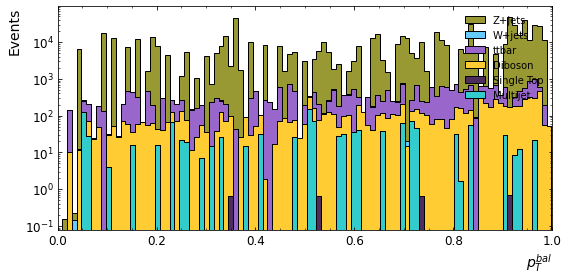

In [18]:
plot_func([qcd_ef_SR, single_top_ef_SR, diboson_ef_SR, ttbar_ef_SR, wjets_ef_SR, zjets_ef_SR], "pt_balance_jets", 
          label_list=["Multijet", "Single Top", "Diboson", "ttbar", "W+jets", "Z+jets"])

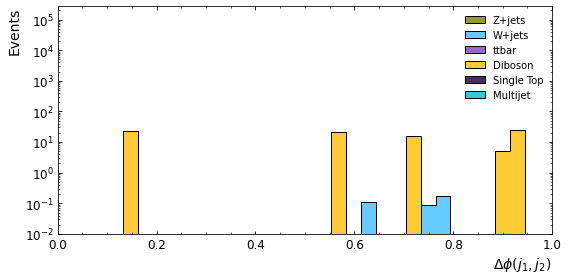

In [19]:
plot_func([qcd_ef_SR, single_top_ef_SR, diboson_ef_SR, ttbar_ef_SR, wjets_ef_SR, zjets_ef_SR], "dphi_j1j2_jets", 
          label_list=["Multijet", "Single Top", "Diboson", "ttbar", "W+jets", "Z+jets"])